# Preparation and EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, MinMaxScaler

from prophet import Prophet
from torch.utils.data import Dataset, DataLoader
import torch
from sklearn.metrics import mean_absolute_error, r2_score
from mango import Tuner

import geopandas as gpd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

d:\University\Diploma\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
data = pd.read_csv('../data/UkraineTuberByRegionByWeek.csv')

In [3]:
data.describe()

,YEAR,WEEK,INFREL
count,60840.00000,60840.000000,60840.000000
mean,2002.00000,26.500000,19.211325
std,12.98728,15.008454,27.110223
min,1980.00000,1.000000,0.000000
25%,1991.00000,13.750000,3.000000
50%,2002.00000,26.500000,11.000000
75%,2013.00000,39.250000,24.000000
max,2024.00000,52.000000,379.000000


In [4]:
data['DATE'] = pd.to_datetime(data['YEAR'].astype(str) + '-' + data['WEEK'].astype(str) + '-1', format='%Y-%W-%w')
data = data.drop(columns=['YEAR', 'WEEK'], axis=1)

<Axes: xlabel='DATE'>

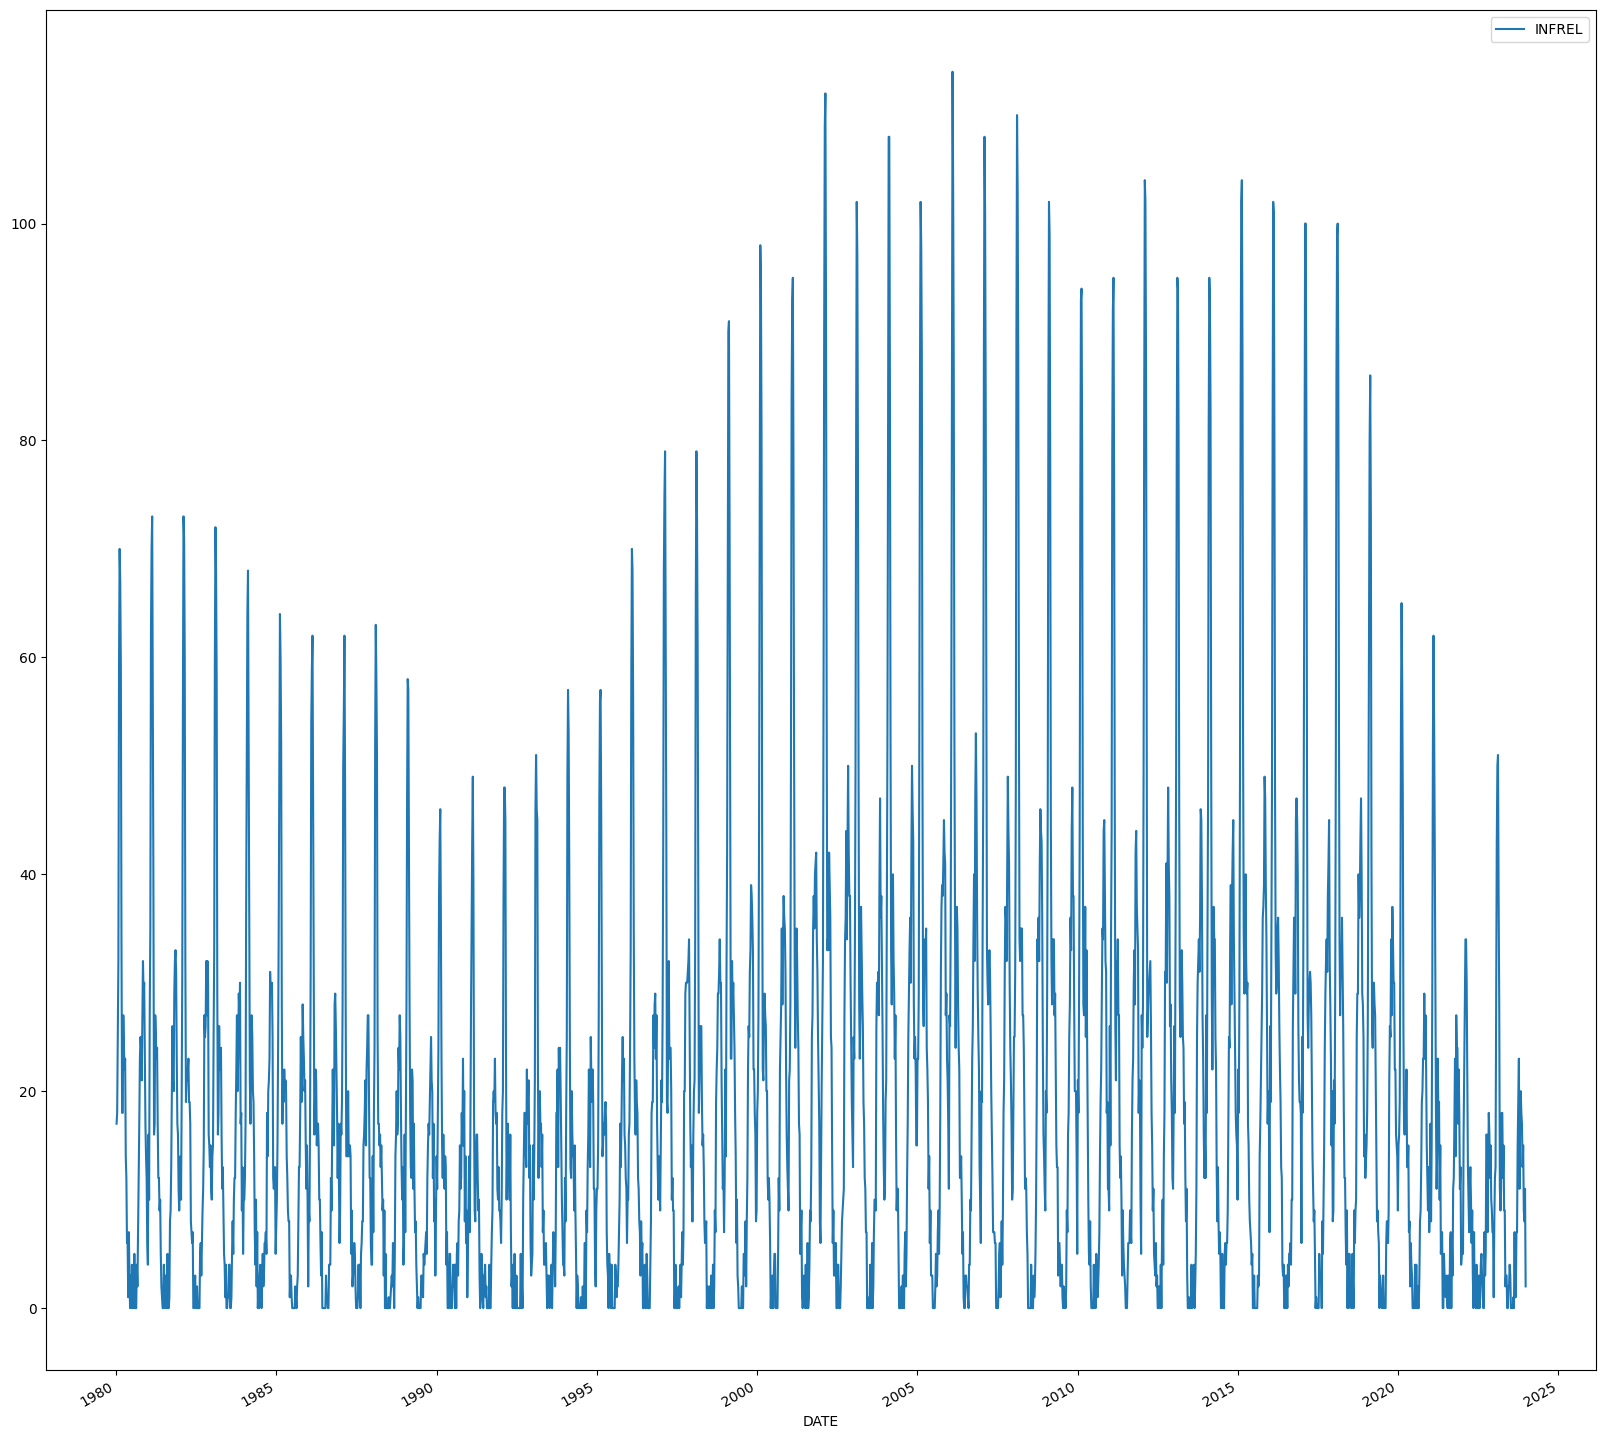

In [5]:
data[(data['REGION'] == 'Zaporizhzhia') & (data['DATE'] > '1980') & (data['DATE'] < '2024')].plot(x='DATE', y='INFREL', figsize=(20, 20))

In [6]:
data_by_region = {region: data[data['REGION'] == region] for region in data['REGION'].unique()}

In [7]:
data_by_region

{'AR Crimea':           REGION  INFREL       DATE
 0      AR Crimea      22 1980-01-07
 1      AR Crimea      19 1980-01-14
 2      AR Crimea      29 1980-01-21
 3      AR Crimea      48 1980-01-28
 4      AR Crimea      88 1980-02-04
 ...          ...     ...        ...
 59535  AR Crimea       0 2024-11-25
 59536  AR Crimea       0 2024-12-02
 59537  AR Crimea       0 2024-12-09
 59538  AR Crimea       0 2024-12-16
 59539  AR Crimea       0 2024-12-23
 
 [2340 rows x 3 columns],
 'Cherkasy':          REGION  INFREL       DATE
 52     Cherkasy      13 1980-01-07
 53     Cherkasy       5 1980-01-14
 54     Cherkasy      16 1980-01-21
 55     Cherkasy      26 1980-01-28
 56     Cherkasy      38 1980-02-04
 ...         ...     ...        ...
 59587  Cherkasy       1 2024-11-25
 59588  Cherkasy       7 2024-12-02
 59589  Cherkasy       6 2024-12-09
 59590  Cherkasy       3 2024-12-16
 59591  Cherkasy       3 2024-12-23
 
 [2340 rows x 3 columns],
 'Chernihiv':           REGION  INFREL     

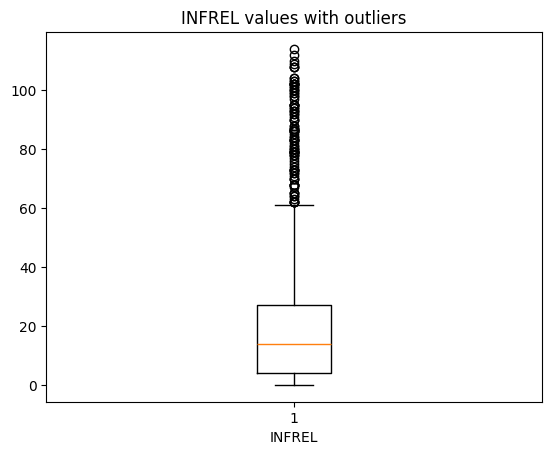

In [8]:
plt.boxplot(data_by_region['Zaporizhzhia']['INFREL'].values)

plt.title('INFREL values with outliers')
plt.xlabel('INFREL')

plt.show()

# DEFINING TRANING

In [9]:
def create_sequences(data, seq_length, predict_length):
    """
    Convert a 1D time series into input/output pairs using a sliding window.
    
    Parameters:
      data: 1D numpy array of time series data.
      seq_length: Number of time steps in the input sequence.
      predict_length: Number of time steps to predict.
      
    Returns:
      X: Array of input sequences of shape (num_samples, seq_length).
      y: Array of target sequences of shape (num_samples, predict_length).
    """
    X, y = [], []
    for i in range(len(data) - seq_length - predict_length + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length : i + seq_length + predict_length])
    return np.array(X), np.array(y)

In [10]:
class SequenceDataset(Dataset):
    """
    Dataset for precomputed sequences.
    
    Each item is an (input, target) pair.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(-1), self.y[idx]

In [11]:
class AnchoredSequenceSplit:
    """
    Split sequences into training and test sets in an anchored (growing) fashion.
    """
    def __init__(self, n_splits):
        self.n_splits = n_splits
        
    def get_n_splits(self):
        return self.n_splits
    
    def split(self, X):
        n_samples = len(X)
        block_size = n_samples // (self.n_splits + 1)
        indices = np.arange(n_samples)
        for i in range(1, self.n_splits + 1):
            train_end = i * block_size
            test_end = (i + 1) * block_size
            yield indices[:train_end], indices[train_end:test_end]

# Additional functions

In [80]:
def plot_ukraine_r2_heatmap(geojson_path, region_r2, algoithm_name='Prophet'):
    gdf = gpd.read_file(geojson_path)

    region_r2['Autonomous Republic of Crimea'] = 0.0
    region_r2['Kiev Oblast'] = region_r2['Kyiv Oblast']
    region_r2['Zaporizhia Oblast'] = region_r2['Zaporizhzhia Oblast']
    r2_df = pd.DataFrame(list(region_r2.items()), columns=["region", "r2_score"])

    gdf["region"] = gdf["name:en"].str.strip().str.lower() 
    r2_df["region"] = r2_df["region"].str.strip().str.lower()

    merged = gdf.merge(r2_df, on="region", how="left")

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    merged.plot(column="r2_score", cmap="coolwarm", linewidth=0.8, edgecolor="black", legend=True, ax=ax)

    for _, row in merged.iterrows():
        centroid = row["geometry"].centroid 
        ax.text(centroid.x, centroid.y, f"{row['region'].title()}\n{row['r2_score']:.2f}",
                fontsize=8, ha='center', color="black", bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    ax.set_title(f"R² Score per Region in Ukraine for {algoithm_name}", fontsize=14)
    plt.axis("off")

    plt.show()

# PROPHET

In [100]:
def validate_prophet(region_full_data, predict_length, prophet_params, region):
    region_full_data = pd.DataFrame(region_full_data, columns=["ds", "y"])
    
    train_data = region_full_data.iloc[:-predict_length]
    test_data = region_full_data.iloc[-predict_length:]

    model = Prophet(**prophet_params, scaling='minmax')
    model.fit(train_data)
    
    future = test_data[['ds']]
    forecast = model.predict(future)
    
    val_forecast = forecast[['ds', 'yhat']].iloc[-predict_length:]
    val_forecast['yhat'] = np.array(val_forecast['yhat'].values).clip(min=0)
    
    merged = test_data.merge(val_forecast, on='ds')
    
    mae = mean_absolute_error(merged['y'], merged['yhat'])
    r2 = r2_score(merged['y'], merged['yhat'])
    
    print(f"Final Metrics {region}: MAE = {mae:.4f}, R^2 = {r2:.4f}")
    
    if region in ['Zaporizhzhia', 'Lviv', 'Kyiv']:
        plt.figure(figsize=(12, 6))
        plt.plot(merged['ds'], merged['y'], label='Actual', marker='o')
        plt.plot(merged['ds'], merged['yhat'], label='Predicted', marker='x')
        plt.xlabel('Date')
        plt.ylabel('Sales')
        plt.title('Actual vs Predicted Values for ' + region)
        plt.legend()
        plt.grid()
        plt.show()
    
    return {"mae": mae, "r2": r2}

In [108]:
def objective_function(args_list, train_data, test_data, PREDICT_LENGTH):
    results = []
    
    for params in args_list:
        try:
            model = Prophet(**params)
            model.fit(train_data)
            future = test_data[['ds']]
            forecast = model.predict(future)
            predictions_tuned = forecast.tail(PREDICT_LENGTH)
            error = mean_absolute_error(test_data['y'], predictions_tuned['yhat'])   
            results.append(error)
        except:
            results.append(25.0)  # Assign high loss for invalid parameter sets

    return results

In [109]:
from scipy.stats import uniform

param_space = {
    'seasonality_prior_scale': uniform(5.0, 15.0),
    'changepoint_prior_scale': uniform(0.01, 0.1),
    'interval_width': uniform(0.2, 0.8)
}

conf_Dict = {'initial_random': 10, 'num_iteration': 50}

In [110]:
def tune_model(train_data, test_data, PREDICT_LENGTH):
    tuner = Tuner(param_space, lambda args: objective_function(args, train_data, test_data, PREDICT_LENGTH), conf_Dict)
    results = tuner.minimize()
    return results['best_params'], results['best_objective']

In [ ]:
PREDICT_LENGTH = 52
PROPHET_PARAMS = {
    'seasonality_mode': 'multiplicative',
    'yearly_seasonality': True,
    'weekly_seasonality': False,
    'daily_seasonality': True,
    'growth': 'linear',
}
regions_mae = {}
regions_r2 = {}

Best score: 25.0: 100%|██████████| 50/50 [01:25<00:00,  1.70s/it]


Region: Cherkasy | Best Params: {'changepoint_prior_scale': 0.10264096154809525, 'interval_width': 0.6669548231677562, 'seasonality_prior_scale': 10.608707787284514} | Best Loss: 25.0


15:50:46 - cmdstanpy - INFO - Chain [1] start processing
15:50:47 - cmdstanpy - INFO - Chain [1] done processing


Final Metrics Cherkasy: MAE = 2.1347, R^2 = 0.4356


Best score: 25.0: 100%|██████████| 50/50 [01:22<00:00,  1.65s/it]


...

Final Metrics Kirovohrad: MAE = 2.7885, R^2 = 0.2411


Best score: 25.0: 100%|██████████| 50/50 [01:25<00:00,  1.71s/it]


Region: Kyiv | Best Params: {'changepoint_prior_scale': 0.10597126750424966, 'interval_width': 0.4405752685025712, 'seasonality_prior_scale': 15.298666580663404} | Best Loss: 25.0


16:05:17 - cmdstanpy - INFO - Chain [1] start processing
16:05:19 - cmdstanpy - INFO - Chain [1] done processing


Final Metrics Kyiv: MAE = 3.0476, R^2 = 0.6932


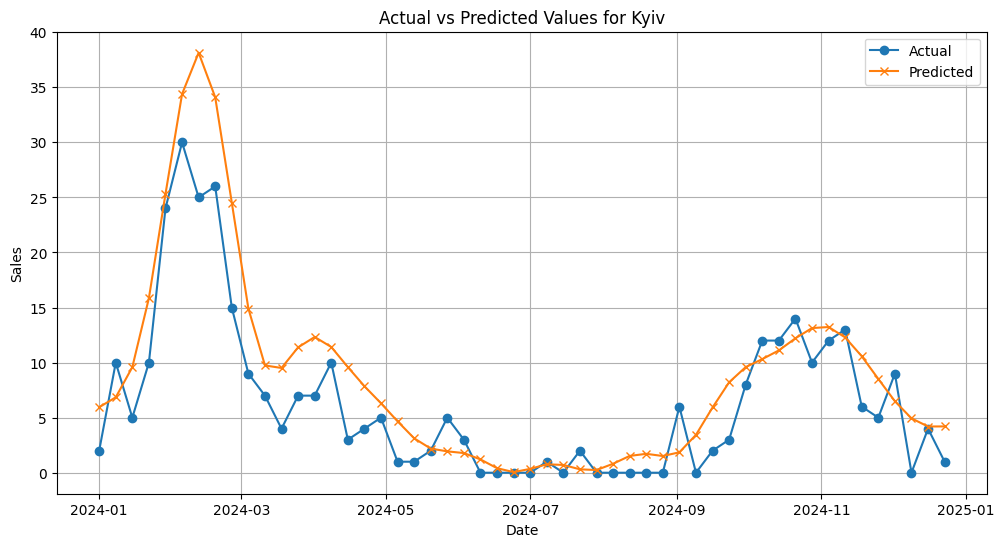

Best score: 25.0: 100%|██████████| 50/50 [01:25<00:00,  1.71s/it]


Region: KyivCity | Best Params: {'changepoint_prior_scale': 0.07757193614162172, 'interval_width': 0.4735544243587674, 'seasonality_prior_scale': 12.421166018606046} | Best Loss: 25.0


16:06:47 - cmdstanpy - INFO - Chain [1] start processing
16:06:47 - cmdstanpy - INFO - Chain [1] done processing


Final Metrics KyivCity: MAE = 2.4317, R^2 = 0.8343


Best score: 25.0: 100%|██████████| 50/50 [01:26<00:00,  1.74s/it]


...

Final Metrics Luhansk: MAE = 2.0695, R^2 = 0.4086


Best score: 25.0: 100%|██████████| 50/50 [01:30<00:00,  1.80s/it]


Region: Lviv | Best Params: {'changepoint_prior_scale': 0.09384320061332735, 'interval_width': 0.282659259068471, 'seasonality_prior_scale': 18.665579998612827} | Best Loss: 25.0


16:09:50 - cmdstanpy - INFO - Chain [1] start processing
16:09:51 - cmdstanpy - INFO - Chain [1] done processing


Final Metrics Lviv: MAE = 3.4629, R^2 = 0.6772


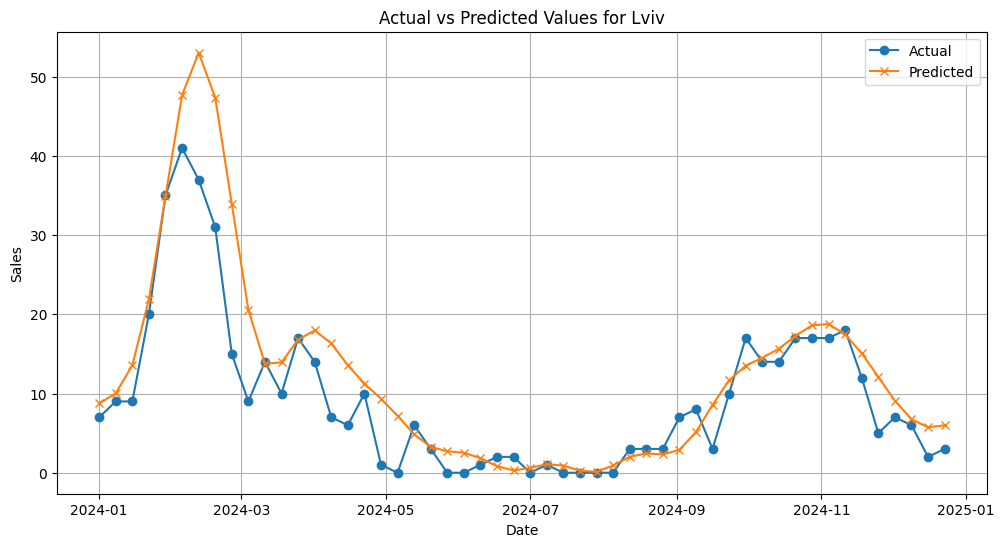

Best score: 25.0: 100%|██████████| 50/50 [01:20<00:00,  1.61s/it]


Region: Mykolaiv | Best Params: {'changepoint_prior_scale': 0.04777018347907403, 'interval_width': 0.8960736206632638, 'seasonality_prior_scale': 7.138011114760488} | Best Loss: 25.0


16:11:14 - cmdstanpy - INFO - Chain [1] start processing
16:11:15 - cmdstanpy - INFO - Chain [1] done processing


Final Metrics Mykolaiv: MAE = 2.5319, R^2 = 0.4868


Best score: 25.0: 100%|██████████| 50/50 [01:26<00:00,  1.73s/it]


...

Final Metrics Zakarpattia: MAE = 6.1007, R^2 = -0.9234


Best score: 25.0: 100%|██████████| 50/50 [01:22<00:00,  1.65s/it]


Region: Zaporizhzhia | Best Params: {'changepoint_prior_scale': 0.09131147578593249, 'interval_width': 0.5234558722436036, 'seasonality_prior_scale': 11.406047988339466} | Best Loss: 25.0


16:24:27 - cmdstanpy - INFO - Chain [1] start processing
16:24:28 - cmdstanpy - INFO - Chain [1] done processing


Final Metrics Zaporizhzhia: MAE = 2.3689, R^2 = 0.7692


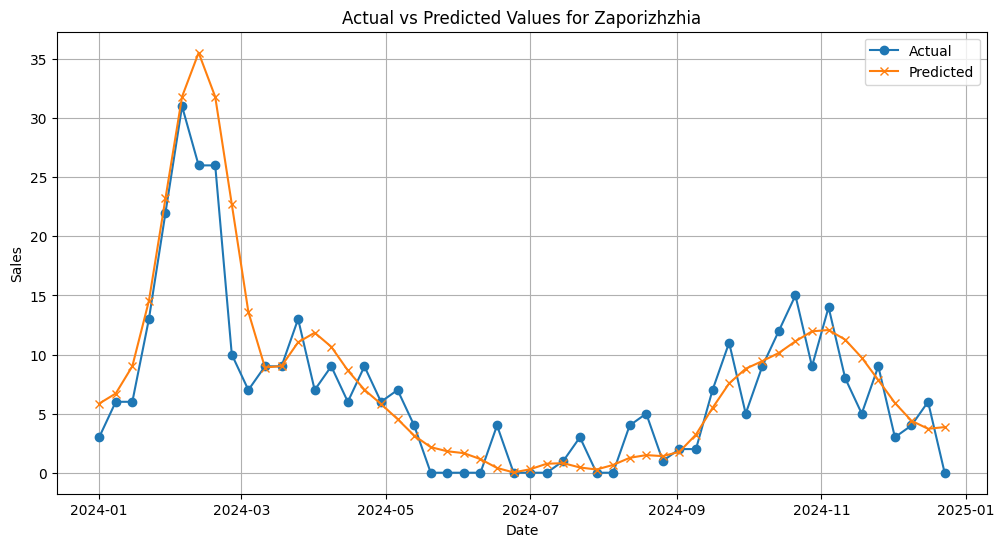

Best score: 25.0: 100%|██████████| 50/50 [01:19<00:00,  1.60s/it]


Region: Zhytomyr | Best Params: {'changepoint_prior_scale': 0.0155972826324313, 'interval_width': 0.840832387092183, 'seasonality_prior_scale': 13.63647966514048} | Best Loss: 25.0


16:25:50 - cmdstanpy - INFO - Chain [1] start processing
16:25:51 - cmdstanpy - INFO - Chain [1] done processing


Final Metrics Zhytomyr: MAE = 2.8030, R^2 = 0.5148


In [112]:
for region in data_by_region.keys():
    if region == 'AR Crimea':
        continue

    PREDICT_LENGTH = 52
    train_data = data_by_region[region][['DATE', 'INFREL']].iloc[:-PREDICT_LENGTH]  
    test_data = data_by_region[region][['DATE', 'INFREL']].iloc[-PREDICT_LENGTH:] 
    best_params, best_loss = tune_model(train_data, test_data, PREDICT_LENGTH)
    
    print(f"Region: {region} | Best Params: {best_params} | Best Loss: {best_loss}")
    
    PROPHET_PARAMS.update(best_params)
    prophet_history = validate_prophet(data_by_region[region][['DATE', 'INFREL']].values, PREDICT_LENGTH, PROPHET_PARAMS, region)
    regions_mae[region] = prophet_history['mae']
    regions_r2[region] = prophet_history['r2']

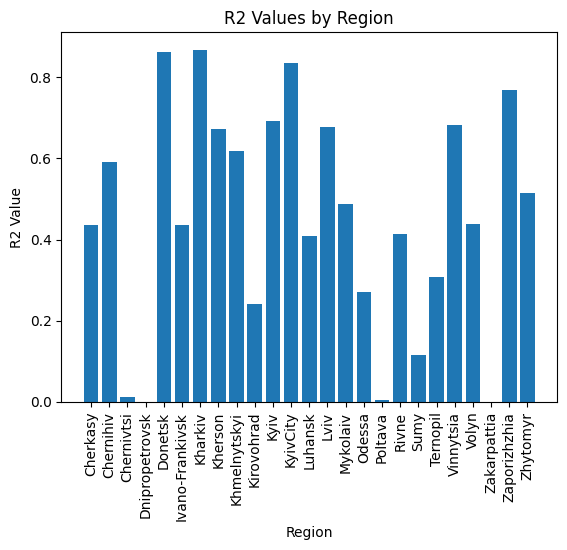

In [113]:
plt.bar(list(data_by_region.keys())[1:], np.array([regions_r2[region] for region in regions_r2.keys()]).clip(min=0))

plt.title('R2 Values by Region')
plt.xlabel('Region')
plt.ylabel('R2 Value')
plt.xticks(rotation=90)
plt.show()

In [152]:
{f'{region} Oblast': max(0, float(regions_r2[region])) for region in regions_r2.keys() if region != 'KyivCity'}

{'Cherkasy Oblast': 0.43560443829951245,
 'Chernihiv Oblast': 0.5908266918820645,
 'Chernivtsi Oblast': 0.01242867602700648,
 'Dnipropetrovsk Oblast': 0,
 'Donetsk Oblast': 0.8631347500341711,
 'Ivano-Frankivsk Oblast': 0.43620394649230954,
 'Kharkiv Oblast': 0.8673485028969635,
 'Kherson Oblast': 0.6727618363168671,
 'Khmelnytskyi Oblast': 0.6171943319158264,
 'Kirovohrad Oblast': 0.2410990737497004,
 'Kyiv Oblast': 0.6931907601570906,
 'Luhansk Oblast': 0.40862427693829684,
 'Lviv Oblast': 0.6772460137800461,
 'Mykolaiv Oblast': 0.48680621183481043,
 'Odessa Oblast': 0.26955111089021877,
 'Poltava Oblast': 0.005181306669656771,
 'Rivne Oblast': 0.414606557489113,
 'Sumy Oblast': 0.11426179886743604,
 'Ternopil Oblast': 0.30839501139055714,
 'Vinnytsia Oblast': 0.681718939584907,
 'Volyn Oblast': 0.4382293896873778,
 'Zakarpattia Oblast': 0,
 'Zaporizhzhia Oblast': 0.7692152458397304,
 'Zhytomyr Oblast': 0.5147873394998244}

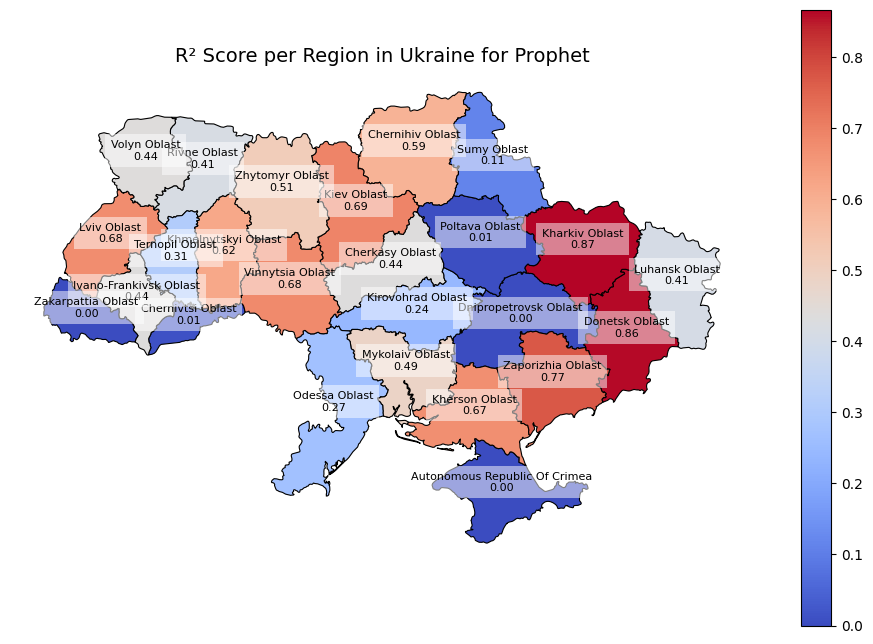

In [43]:
regions_to_r2 = {region: max(0, float(regions_r2[region])) for region in regions_r2.keys() if region != 'KyivCity'}
plot_ukraine_r2_heatmap('D:/University/Diploma/data/UA_FULL_Ukraine.geojson', regions_to_r2)

# SARIMA

In [87]:
def seasonal_decomposition(region, model="multiplicative", period=52):
    dates = data_by_region[region]["DATE"].sort_values().values
    region_data = data_by_region[region].sort_values(by="DATE").apply(lambda x: x['INFREL']+0.001 if (x['INFREL'] == 0 and model == "multiplicative") else x['INFREL'], axis=1)
    time_series = region_data.values

    result = seasonal_decompose(time_series, model=model, period=period)

    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(dates, result.observed, label="Observed", color="black")
    axes[0].set_title("Observed")

    axes[1].plot(dates, result.trend, label="Trend", color="blue")
    axes[1].set_title("Trend")

    axes[2].plot(dates, result.seasonal, label="Seasonality", color="green")
    axes[2].set_title("Seasonality")

    axes[3].plot(dates, result.resid, label="Residuals", color="red")
    axes[3].set_title("Residuals")

    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()

    return result

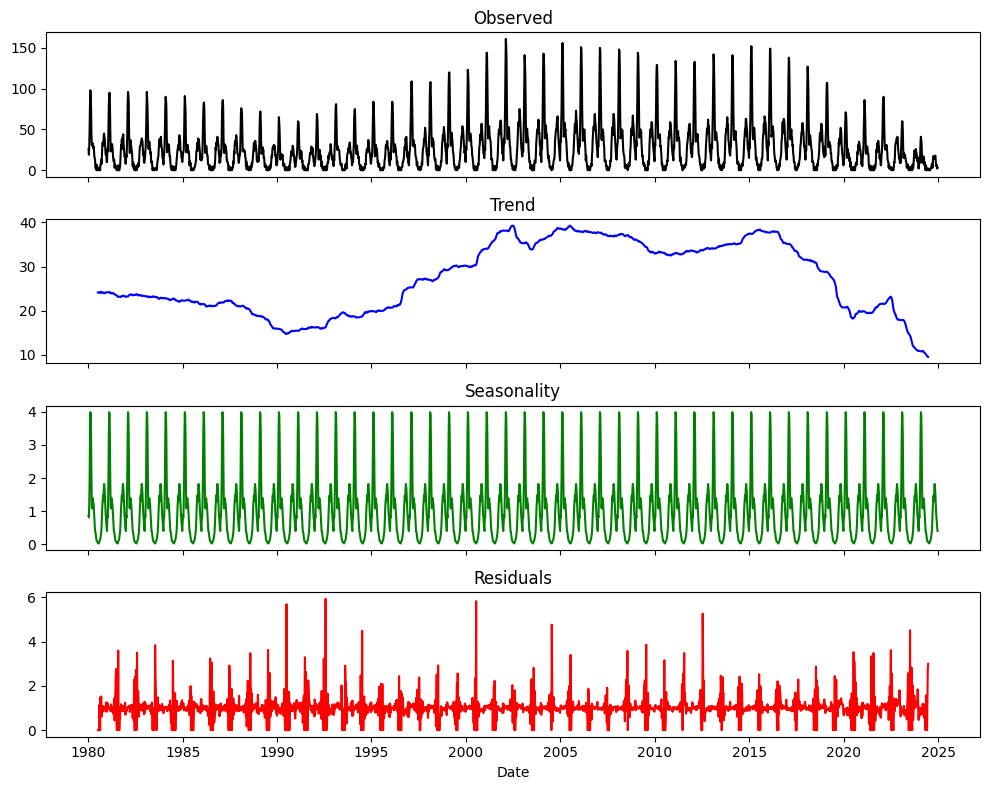

In [88]:
result = seasonal_decomposition(region="Lviv", model='multiplicative', period=52)

There is seasonality in this data, so it can't be stationary.

To make data stationary we need to get rid off seasonality and trend

In [89]:
def clear_trend_seasonality(region, period=52):
    region_data = data_by_region[region].sort_values(by="DATE").copy(deep=True)

    # Apply log transformation to handle multiplicative seasonality
    region_data["INFREL"] = np.log1p(region_data["INFREL"])

    # Plot original (log-transformed) data
    # plt.figure(figsize=(10, 4))
    # plt.plot(region_data["DATE"], region_data["INFREL"], label="Log-Transformed INFREL")
    # plt.legend()
    # plt.show()

    # First-order differencing (to remove trend)
    deseasonalized_data = region_data.copy()
    deseasonalized_data["INFREL"] = region_data["INFREL"].diff()

    deseasonalized_data = deseasonalized_data.dropna()

    # plt.figure(figsize=(10, 4))
    # plt.plot(deseasonalized_data["DATE"], deseasonalized_data["INFREL"], label="Deseasonalized INFREL")
    # plt.legend()
    # plt.show()

    # Seasonal differencing (to remove seasonal effect)
    # detrended_data = deseasonalized_data.copy()
    detrended_data = region_data.copy()
    detrended_data["INFREL"] = deseasonalized_data["INFREL"].diff(period)

    # Drop NaN values
    detrended_data = detrended_data.dropna()

    # Plot transformed data
    # plt.figure(figsize=(10, 4))
    # plt.plot(detrended_data["DATE"], detrended_data["INFREL"], label="Detrended INFREL")
    # plt.legend()
    # plt.show()

    return detrended_data

In [54]:
def plot_acf_pacf(df): 
    fig, ax = plt.subplots(2, 1, figsize=(12, 8))

    plot_acf(df["INFREL"].dropna(), lags=156, ax=ax[0])  # ACF for MA(q)
    ax[0].set_title("Autocorrelation Function (ACF)")

    plot_pacf(df["INFREL"].dropna(), lags=156, ax=ax[1])  # PACF for AR(p)
    ax[1].set_title("Partial Autocorrelation Function (PACF)")

    plt.show()

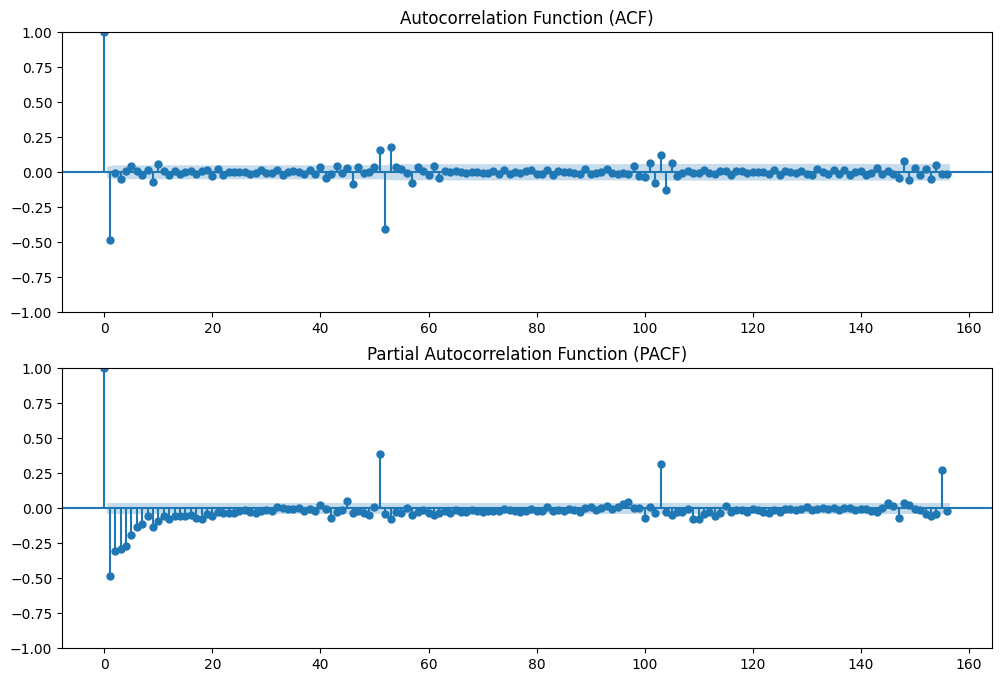

In [55]:
plot_acf_pacf(clear_trend_seasonality(region="Lviv", period=52))

In [94]:
def sarima_forecast(data, region, order=(1, 1, 1), seasonal_order=(0, 1, 1, 52)):
    """
    Train SARIMA on the raw dataset (no detrending or deseasonalizing) and validate on the last 52 observations.

    Args:
        data (DataFrame): DataFrame with 'DATE' and 'INFREL' columns.
        order (tuple): Non-seasonal ARIMA order (p, d, q).
        seasonal_order (tuple): Seasonal order (P, D, Q, s).

    Returns:
        results_df (DataFrame): DataFrame with predictions and actuals for the last 52 values.
        model_fit: Fitted SARIMA model.
    """
    # Sort data by date
    data = data.sort_values(by="DATE")

    # Define training and validation split
    train_size = len(data) - 52  # Use all but the last 52 points for training
    train_series = data["INFREL"][:train_size].values
    val_series = data["INFREL"][train_size:].values
    val_dates = data["DATE"][train_size:].values

    # Train SARIMA model on raw data
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
        trend='ct'
    )
    model_fit = model.fit(disp=True)

    # Forecast the next 52 steps
    predictions = model_fit.forecast(steps=52)

    # Evaluate performance
    val_mae = mean_absolute_error(val_series, predictions)
    val_r2 = r2_score(val_series, predictions)

    print('Region', region, f"Validation MAE: {val_mae:.2f}", f"Validation R²: {val_r2:.2f}")

    # Store results in DataFrame
    results_df = pd.DataFrame({
        "Date": val_dates,
        "Actual_INFREL": val_series,
        "Predicted_INFREL": predictions
    })

    if region in ['Donetsk', 'Lviv', 'Kyiv']:
        # Plot forecasted vs actual values
        plt.figure(figsize=(10, 6))
        plt.plot(results_df["Date"], results_df["Predicted_INFREL"], label="Forecasted", linestyle="dashed", color="red")
        plt.plot(results_df["Date"], results_df["Actual_INFREL"], label="Actual", alpha=0.7, color="blue")
        plt.xlabel("Date")
        plt.ylabel("INFREL")
        plt.title("Forecasted vs Actual INFREL (Raw Data)")
        plt.legend()
        plt.xticks(rotation=45)
        plt.show()

    return results_df, model_fit, val_mae, val_r2

In [ ]:
regions_r2 = {}
regions_mae = {}


In [ ]:
for region in data_by_region.keys():
    if region == 'AR Crimea':
        continue

    forecast_results, sarima_model, val_mae, val_r2 = sarima_forecast(data_by_region[region], region, order=(0, 0, 0), seasonal_order=(0, 1, 0, 52))
    regions_mae[region] = val_mae
    regions_r2[region] = val_r2

Region Cherkasy Validation MAE: 3.45 Validation R²: -0.58
Region Chernihiv Validation MAE: 3.86 Validation R²: -0.74
Region Chernivtsi Validation MAE: 2.84 Validation R²: -1.24
Region Dnipropetrovsk Validation MAE: 13.86 Validation R²: -0.41
Region Donetsk Validation MAE: 5.76 Validation R²: 0.43


d:\University\Diploma\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Region Ivano-Frankivsk Validation MAE: 3.27 Validation R²: -0.17
Region Kharkiv Validation MAE: 4.81 Validation R²: 0.47
Region Kherson Validation MAE: 4.60 Validation R²: -0.13
Region Khmelnytskyi Validation MAE: 3.50 Validation R²: 0.08
Region Kirovohrad Validation MAE: 4.19 Validation R²: -0.84
Region Kyiv Validation MAE: 5.58 Validation R²: -0.16
Region KyivCity Validation MAE: 4.66 Validation R²: 0.32
Region Luhansk Validation MAE: 3.29 Validation R²: -0.60
Region Lviv Validation MAE: 5.17 Validation R²: 0.49
Region Mykolaiv Validation MAE: 4.13 Validation R²: -0.44
Region Odessa Validation MAE: 11.70 Validation R²: 0.23
Region Poltava Validation MAE: 4.50 Validation R²: -1.16
Region Rivne Validation MAE: 3.50 Validation R²: -0.59
Region Sumy Validation MAE: 3.85 Validation R²: -1.94


d:\University\Diploma\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Region Ternopil Validation MAE: 2.34 Validation R²: -0.59
Region Vinnytsia Validation MAE: 3.41 Validation R²: 0.07
Region Volyn Validation MAE: 3.37 Validation R²: -0.20
Region Zakarpattia Validation MAE: 4.46 Validation R²: 0.05
Region Zaporizhzhia Validation MAE: 5.32 Validation R²: -0.22
Region Zhytomyr Validation MAE: 3.48 Validation R²: 0.16


{'Cherkasy': -0.5803990213003456,
 'Chernihiv': -0.7392136292268379,
 'Chernivtsi': -1.238553914668294,
 'Dnipropetrovsk': -0.41367225312793376,
 'Donetsk': 0.4261564774482267,
 'Ivano-Frankivsk': -0.16515289896540297,
 'Kharkiv': 0.47040919866356956,
 'Kherson': -0.13350150373019387,
 'Khmelnytskyi': 0.07657316796886482,
 'Kirovohrad': -0.83658043409447,
 'Kyiv': -0.16483277845267574,
 'KyivCity': 0.31524990698582356,
 'Luhansk': -0.6020386890780791,
 'Lviv': 0.49026421620775806,
 'Mykolaiv': -0.43657518710990906,
 'Odessa': 0.23350535095734026,
 'Poltava': -1.1581016905435506,
 'Rivne': -0.5852179854101889,
 'Sumy': -1.941063257375038,
 'Ternopil': -0.5909050806509173,
 'Vinnytsia': 0.07164529190646407,
 'Volyn': -0.2049143578972077,
 'Zakarpattia': 0.05302953854803094,
 'Zaporizhzhia': -0.22058834809548533,
 'Zhytomyr': 0.1616857958845539}

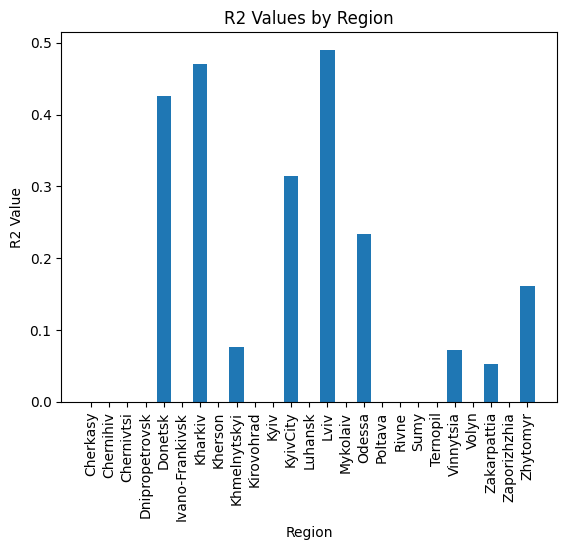

In [69]:
plt.bar(list(data_by_region.keys())[1:], np.array([regions_r2[region] for region in regions_r2.keys()]).clip(min=0))

plt.title('R2 Values by Region')
plt.xlabel('Region')
plt.ylabel('R2 Value')
plt.xticks(rotation=90)
plt.show()

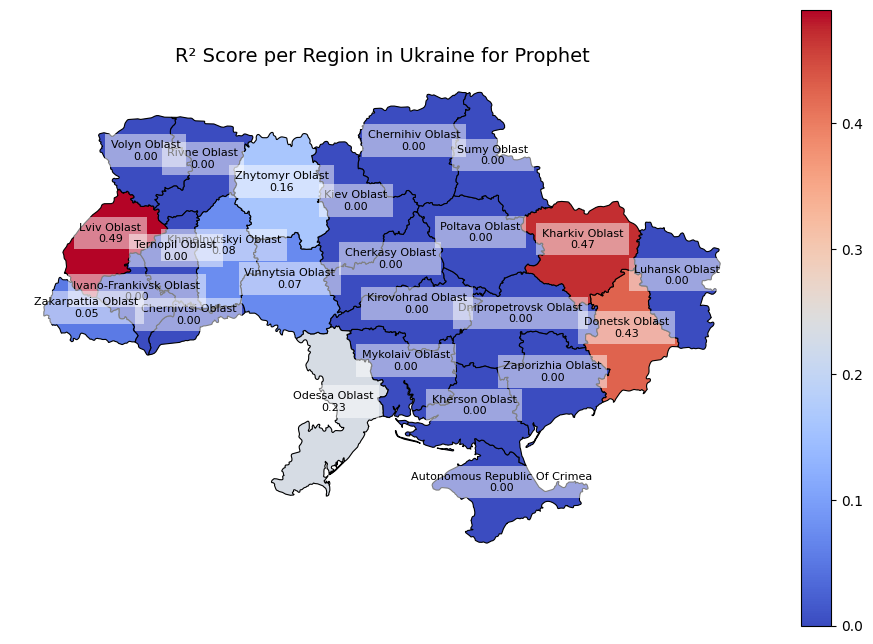

In [82]:
regions_to_r2 = {f"{region} Oblast": max(0, float(regions_r2[region])) for region in regions_r2.keys() if region != 'KyivCity'}
plot_ukraine_r2_heatmap('D:/University/Diploma/data/UA_FULL_Ukraine.geojson', regions_to_r2)